# Giai đoạn 4: Xây dựng và Huấn luyện mô hình AI/ML (Model Training)

Mục tiêu của giai đoạn này là xây dựng các mô hình học máy để dự báo Nhiệt độ (`temp`) cho giờ tiếp theo dựa trên các đặc trưng thời tiết hiện tại và quá khứ.

Chúng ta sẽ phát triển và so sánh 3 mô hình:
1. **Mô hình Hồi quy Tuyến tính (Linear Regression) - Baseline:** Làm mốc so sánh cơ bản.
2. **Mô hình XGBoost Regressor (Machine Learning):** Mô hình cây quyết định tăng cường mạnh mẽ cho dữ liệu bảng.
3. **Mô hình LSTM - Long Short-Term Memory (Deep Learning):** Mô hình mạng nơ-ron hồi quy chuyên sâu cho chuỗi thời gian.

### Quy trình thực hiện:
- Đọc dữ liệu sạch từ bảng `processed_weather` của SQLite database.
- Chia dữ liệu thành tập Huấn luyện (Train) và Kiểm thử (Test) theo mốc thời gian (không chia ngẫu nhiên để tránh rò rỉ dữ liệu).
- Chuẩn hóa dữ liệu (Scaling) bằng `MinMaxScaler` và lưu trữ bộ chuẩn hóa để dùng cho Backend.
- Huấn luyện các mô hình và đánh giá sai số bằng các chỉ số: MAE, RMSE, MAPE.
- So sánh trực quan hóa kết quả thực tế vs dự báo của các mô hình.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Kiểm tra TensorFlow cho mô hình LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print(f"TensorFlow Version: {tf.__version__}")
print(f"XGBoost Version: {xgb.__version__}")

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

/Users/quangnguyentamhuu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


TensorFlow Version: 2.21.0
XGBoost Version: 2.1.1


## 1. Tải dữ liệu từ SQLite Database

In [2]:
# Kết nối cơ sở dữ liệu và tải dữ liệu đã tiền xử lý
conn = sqlite3.connect("../data/database/weather_data.db")
truy_van = "SELECT * FROM processed_weather"
df = pd.read_sql_query(truy_van, conn)
conn.close()

# Chuyển cột time về dạng datetime
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(by=['city', 'time'])

print(f"Kích thước dữ liệu sạch: {df.shape} (Dòng, Cột)")
print(f"Các cột đặc trưng: \n{df.columns.tolist()}")

Kích thước dữ liệu sạch: (272938, 49) (Dòng, Cột)
Các cột đặc trưng: 
['time', 'city', 'station_id', 'temp', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'coco', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_lag_1h', 'temp_lag_2h', 'temp_lag_3h', 'temp_lag_6h', 'temp_lag_12h', 'temp_lag_24h', 'rhum_lag_1h', 'rhum_lag_2h', 'rhum_lag_3h', 'rhum_lag_6h', 'rhum_lag_12h', 'rhum_lag_24h', 'prcp_lag_1h', 'prcp_lag_2h', 'prcp_lag_3h', 'prcp_lag_6h', 'prcp_lag_12h', 'prcp_lag_24h', 'wspd_lag_1h', 'wspd_lag_2h', 'wspd_lag_3h', 'wspd_lag_6h', 'wspd_lag_12h', 'wspd_lag_24h', 'temp_roll_mean_6h', 'temp_roll_std_6h', 'temp_roll_mean_24h', 'temp_roll_std_24h', 'rhum_roll_mean_6h', 'rhum_roll_std_6h', 'rhum_roll_mean_24h', 'rhum_roll_std_24h']


## 2. Phân chia tập dữ liệu (Train/Test Split)
Đối với bài toán dữ liệu chuỗi thời gian, việc sử dụng các hàm chia ngẫu nhiên sẽ làm mô hình biết trước thông tin tương lai để dự báo quá khứ (Rò rỉ dữ liệu - Data Leakage).
Chúng ta chia tập dữ liệu theo mốc thời gian rõ ràng:
- **Tập Train (Huấn luyện):** Từ năm 2016 đến hết ngày 31/12/2024 (Khoảng 9 năm dữ liệu để mô hình học đủ quy luật).
- **Tập Test (Kiểm thử):** Từ ngày 01/01/2025 đến hết 22/05/2026 (Khoảng 1.4 năm dữ liệu thực tế gần đây để đánh giá độc lập).

In [3]:
# Mốc thời gian phân chia
moc_chia = pd.to_datetime("2025-01-01 00:00:00")

# Phân chia tập dữ liệu
df_train = df[df['time'] < moc_chia].copy()
df_test = df[df['time'] >= moc_chia].copy()

print(f"Tập Train: {df_train.shape[0]} dòng (từ {df_train['time'].min()} đến {df_train['time'].max()})")
print(f"Tập Test : {df_test.shape[0]} dòng (từ {df_test['time'].min()} đến {df_test['time'].max()})")

# Thống kê số lượng dòng của mỗi thành phố trong 2 tập
print("\nSố lượng dòng trong tập Train theo thành phố:")
print(df_train['city'].value_counts())
print("\nSố lượng dòng trong tập Test theo thành phố:")
print(df_test['city'].value_counts())

Tập Train: 236437 dòng (từ 2016-01-02 00:00:00 đến 2024-12-31 23:00:00)
Tập Test : 36501 dòng (từ 2025-01-01 00:00:00 đến 2026-05-22 22:00:00)

Số lượng dòng trong tập Train theo thành phố:
city
Ha Noi     78845
TP HCM     78840
Da Nang    78752
Name: count, dtype: int64

Số lượng dòng trong tập Test theo thành phố:
city
Da Nang    12167
Ha Noi     12167
TP HCM     12167
Name: count, dtype: int64


## 3. Chuẩn hóa dữ liệu (Feature Scaling)
Để các thuật toán (đặc biệt là LSTM) hội tụ tốt hơn, chúng ta đưa dữ liệu về khoảng `[0, 1]` bằng `MinMaxScaler`.

**Quy tắc vô cùng quan trọng:** Chỉ `.fit()` bộ chuẩn hóa trên tập Train, sau đó dùng bộ đã fit để `.transform()` cho cả tập Train và Test. Điều này đảm bảo tuyệt đối không có rò rỉ thông tin về biên độ dữ liệu tương lai vào tập huấn luyện.

In [4]:
# Xác định các cột đầu vào (Features) và cột mục tiêu (Target)
cac_cot_loai_bo = ['time', 'station_id', 'city', 'temp'] #temp là biến mục tiêu
cac_dac_trung = [col for col in df.columns if col not in cac_cot_loai_bo]
bien_muc_tieu = 'temp'

print(f"Số lượng đặc trưng đầu vào: {len(cac_dac_trung)}")

# Khởi tạo bộ chuẩn hóa MinMaxScaler
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# Fit scaler trên tập Train
scaler_features.fit(df_train[cac_dac_trung])
scaler_target.fit(df_train[[bien_muc_tieu]])

# Tiến hành chuyển đổi dữ liệu (Transform)
X_train_scaled = scaler_features.transform(df_train[cac_dac_trung])
y_train_scaled = scaler_target.transform(df_train[[bien_muc_tieu]]).flatten()

X_test_scaled = scaler_features.transform(df_test[cac_dac_trung])
y_test_scaled = scaler_target.transform(df_test[[bien_muc_tieu]]).flatten()

# Lưu trữ bộ chuẩn hóa để phục vụ Inference ở API Backend sau này
joblib.dump(scaler_features, '../models/preprocessors/scaler_features.pkl')
joblib.dump(scaler_target, '../models/preprocessors/scaler_target.pkl')
print("-> Đã lưu thành công scaler_features.pkl và scaler_target.pkl!")

Số lượng đặc trưng đầu vào: 45
-> Đã lưu thành công scaler_features.pkl và scaler_target.pkl!


## 4. Định nghĩa Hàm đánh giá sai số (Evaluation Metrics)
Chúng ta sẽ định nghĩa hàm tính toán các chỉ số lỗi:
- **MAE (Mean Absolute Error):** Đo độ lệch tuyệt đối trung bình so với nhiệt độ thực tế (tính bằng °C).
- **RMSE (Root Mean Squared Error):** Căn bậc 2 của sai số bình phương trung bình, giúp đo lường mức độ ảnh hưởng của các lỗi dự báo lớn.
- **MAPE (Mean Absolute Percentage Error):** Sai số phần trăm tuyệt đối trung bình, đo tỷ lệ phần trăm sai lệch.

In [5]:
def tinh_mape(y_true, y_pred):
    # Tránh chia cho 0
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def danh_gia_mo_hinh(y_true, y_pred, ten_mo_hinh):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = tinh_mape(y_true, y_pred)
    
    print(f"=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: {ten_mo_hinh.upper()} ===")
    print(f"  MAE  (Sai số tuyệt đối TB)     : {mae:.3f} °C")
    print(f"  RMSE (Căn sai số bình phương TB): {rmse:.3f} °C")
    print(f"  MAPE (Sai số phần trăm TB)     : {mape:.3f} %")
    print("=" * 40)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

## 5. Mô hình 1: Hồi quy Tuyến tính (Linear Regression) - Baseline
Mô hình Hồi quy tuyến tính sẽ sử dụng các đặc trưng trễ và trượt đã tính toán sẵn dưới dạng bảng 2D thông thường để huấn luyện cực kỳ nhanh chóng.

In [6]:
# Khởi tạo và huấn luyện mô hình
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled)

# Dự báo trên tập Test
y_pred_scaled_lr = lr_model.predict(X_test_scaled)

# Chuyển đổi ngược lại giá trị nhiệt độ thực tế về đơn vị ban đầu (°C)
y_pred_lr = scaler_target.inverse_transform(y_pred_scaled_lr.reshape(-1, 1)).flatten()
y_test_real = df_test[bien_muc_tieu].values

# Đánh giá
ket_qua_lr = danh_gia_mo_hinh(y_test_real, y_pred_lr, "Linear Regression (Baseline)")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: LINEAR REGRESSION (BASELINE) ===
  MAE  (Sai số tuyệt đối TB)     : 0.336 °C
  RMSE (Căn sai số bình phương TB): 0.452 °C
  MAPE (Sai số phần trăm TB)     : 1.326 %


## 6. Mô hình 2: XGBoost Regressor
XGBoost là thuật toán học máy nâng cao hiệu năng rất cao, chuyên trị các dữ liệu bảng và chuỗi thời gian phi tuyến phức tạp.

In [7]:
# Khởi tạo mô hình XGBoost với các siêu tham số tiêu chuẩn
xgb_model = xgb.XGBRegressor(
    n_estimators=150,      # Số lượng cây quyết định
    max_depth=6,           # Độ sâu tối đa của mỗi cây
    learning_rate=0.08,    # Tốc độ học tập
    subsample=0.8,         # Tỷ lệ lấy mẫu dòng khi dựng cây
    colsample_bytree=0.8,  # Tỷ lệ lấy mẫu cột khi dựng cây
    random_state=42,
    n_jobs=-1              # Sử dụng tối đa nhân CPU để song song hóa
)

# Huấn luyện mô hình (Thời gian chạy cục bộ khoảng 30s - 1 phút)
xgb_model.fit(
    X_train_scaled, y_train_scaled,
    eval_set=[(X_test_scaled, y_test_scaled)],
    verbose=20
)

# Dự báo trên tập Test
y_pred_scaled_xgb = xgb_model.predict(X_test_scaled)
y_pred_xgb = scaler_target.inverse_transform(y_pred_scaled_xgb.reshape(-1, 1)).flatten()

# Đánh giá
ket_qua_xgb = danh_gia_mo_hinh(y_test_real, y_pred_xgb, "XGBoost Regressor")

# Lưu mô hình XGBoost vào file JSON phục vụ suy diễn sau này
xgb_model.save_model("../models/trained/xgboost_weather_model.json")
print("-> Đã lưu mô hình ../models/trained/xgboost_weather_model.json thành công!")

[0]	validation_0-rmse:0.12072
[20]	validation_0-rmse:0.02992
[40]	validation_0-rmse:0.01729
[60]	validation_0-rmse:0.01484
[80]	validation_0-rmse:0.01379
[100]	validation_0-rmse:0.01325
[120]	validation_0-rmse:0.01292
[140]	validation_0-rmse:0.01268
[149]	validation_0-rmse:0.01258
=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: XGBOOST REGRESSOR ===
  MAE  (Sai số tuyệt đối TB)     : 0.316 °C
  RMSE (Căn sai số bình phương TB): 0.440 °C
  MAPE (Sai số phần trăm TB)     : 1.250 %
-> Đã lưu mô hình ../models/trained/xgboost_weather_model.json thành công!


## 7. Mô hình 3: Deep Learning LSTM (Long Short-Term Memory)
Mạng LSTM yêu cầu dữ liệu đầu vào phải có dạng 3 chiều (3D Tensor): `(Kích thước mẫu, Số bước thời gian - time steps, Số đặc trưng - features)`.

Chúng ta chọn **bước thời gian là 24 (24 giờ qua)** để dự báo nhiệt độ của giờ tiếp theo. Để tránh hiện tượng rò rỉ dữ liệu và ô nhiễm chuỗi thời gian giữa các thành phố, chúng ta phải tạo các chuỗi 3D độc lập theo từng thành phố.

In [8]:
# Lựa chọn các đặc trưng hiện tại (không dùng cột đặc trưng trễ đã tính sẵn của 2D)
# để LSTM tự học từ chuỗi thời gian liên tiếp
dac_trung_lstm = ['temp', 'rhum', 'prcp', 'wspd', 'wdir', 'pres', 'coco', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
num_features = len(dac_trung_lstm)

# Tạo Scaler riêng cho tập LSTM để dễ quản lý dữ liệu gốc
scaler_lstm_features = MinMaxScaler(feature_range=(0,1))
scaler_lstm_features.fit(df_train[dac_trung_lstm])

def tao_chuoi_du_lieu_lstm(df_data, scaler_fit, seq_len=24):
    X_list, y_list = [], []
    
    # Nhóm theo thành phố để tạo chuỗi độc lập
    for ten_thanh_pho, nhom in df_data.groupby('city'):
        nhom_sorted = nhom.sort_values('time')
        
        # Chuẩn hóa các cột đặc trưng của nhóm
        nhom_scaled = scaler_fit.transform(nhom_sorted[dac_trung_lstm])
        nhom_target = nhom_sorted['temp'].values
        
        # Tạo chuỗi trượt 24 bước thời gian
        for i in range(seq_len, len(nhom_scaled)):
            X_list.append(nhom_scaled[i-seq_len : i])
            y_list.append(nhom_target[i])
            
    return np.array(X_list), np.array(y_list)

# Tạo bộ dữ liệu 3D cho LSTM
X_train_lstm, y_train_lstm = tao_chuoi_du_lieu_lstm(df_train, scaler_lstm_features, seq_len=24)
X_test_lstm, y_test_lstm = tao_chuoi_du_lieu_lstm(df_test, scaler_lstm_features, seq_len=24)

print(f"Kích thước tập Train LSTM 3D: X={X_train_lstm.shape}, y={y_train_lstm.shape}")
print(f"Kích thước tập Test LSTM 3D : X={X_test_lstm.shape}, y={y_test_lstm.shape}")

# Lưu scaler LSTM
joblib.dump(scaler_lstm_features, '../models/preprocessors/scaler_lstm_features.pkl')
print("-> Đã lưu scaler_lstm_features.pkl thành công!")

Kích thước tập Train LSTM 3D: X=(236365, 24, 11), y=(236365,)
Kích thước tập Test LSTM 3D : X=(36429, 24, 11), y=(36429,)
-> Đã lưu scaler_lstm_features.pkl thành công!


### 7.2. Xây dựng Kiến trúc mạng LSTM bằng TensorFlow Keras
Kiến trúc gồm:
- 1 tầng LSTM chính (64 units) để học thông tin chuỗi.
- Tầng Dropout (20%) giúp hạn chế Overfitting.
- 1 tầng Dense ẩn (16 units) trung gian.
- Tầng Dense đầu ra (1 unit) để dự báo nhiệt độ liên tục.

In [9]:
# Xây dựng mô hình LSTM
model_lstm = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Dự báo một giá trị nhiệt độ duy nhất ở giờ t
])

# Compile mô hình với optimizer Adam và loss function MSE
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

/Users/quangnguyentamhuu/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,513 (80.13 KB)

 Trainable params: 20,513 (80.13 KB)

 Non-trainable params: 0 (0.00 B)

### 7.3. Huấn luyện mô hình LSTM
Thời gian chạy ước tính trên CPU là khoảng 5-10 phút. Nếu bạn chạy trên môi trường Kaggle/Google Colab có GPU, thời gian chạy sẽ rút ngắn xuống còn 1-2 phút.

In [10]:
# Để huấn luyện đầy đủ, thiết lập epochs=10 hoặc 15.
# Ở đây chúng ta để epochs=10, batch_size=256 để cân bằng giữa tốc độ và độ chính xác.
lich_su = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=10,
    batch_size=256,
    verbose=1
)

# Dự báo trên tập Test
y_pred_lstm = model_lstm.predict(X_test_lstm, batch_size=512).flatten()

# Đánh giá
ket_qua_lstm = danh_gia_mo_hinh(y_test_lstm, y_pred_lstm, "Mạng LSTM Deep Learning")

# Lưu mô hình LSTM
model_lstm.save("../models/trained/lstm_weather_model.keras")
print("-> Đã lưu mô hình ../models/trained/lstm_weather_model.keras thành công!")

Epoch 1/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 107s 94ms/step - loss: 48.8343 - val_loss: 14.8538
Epoch 2/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 51s 56ms/step - loss: 7.8901 - val_loss: 1.7027
Epoch 3/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 67s 73ms/step - loss: 4.2746 - val_loss: 1.1998
Epoch 4/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - loss: 3.8437 - val_loss: 1.6684
Epoch 5/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 93s 101ms/step - loss: 3.5029 - val_loss: 0.9652
Epoch 6/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 117s 127ms/step - loss: 3.1758 - val_loss: 0.8710
Epoch 7/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 62s 67ms/step - loss: 2.8168 - val_loss: 0.8349
Epoch 8/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - loss: 2.4265 - val_loss: 0.7563
Epoch 9/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - loss: 2.0409 - val_loss: 0.7652
Epoch 10/10
924/924 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - loss: 1.6924 - val_loss: 0.7633
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: MẠNG LSTM DEEP LEARNING ===
  MAE  (Sai số 

## 8. So sánh và Trực quan hóa kết quả dự báo
Chúng ta tổng hợp kết quả của cả 3 mô hình lên biểu đồ để so sánh trực quan sai số.

=== BẢNG SO SÁNH SAI SỐ CÁC MÔ HÌNH ===
                         MAE      RMSE      MAPE
Linear Regression   0.336342  0.451980  1.326069
XGBoost Regressor   0.316396  0.440141  1.250024
LSTM Deep Learning  0.630782  0.873674  2.509778


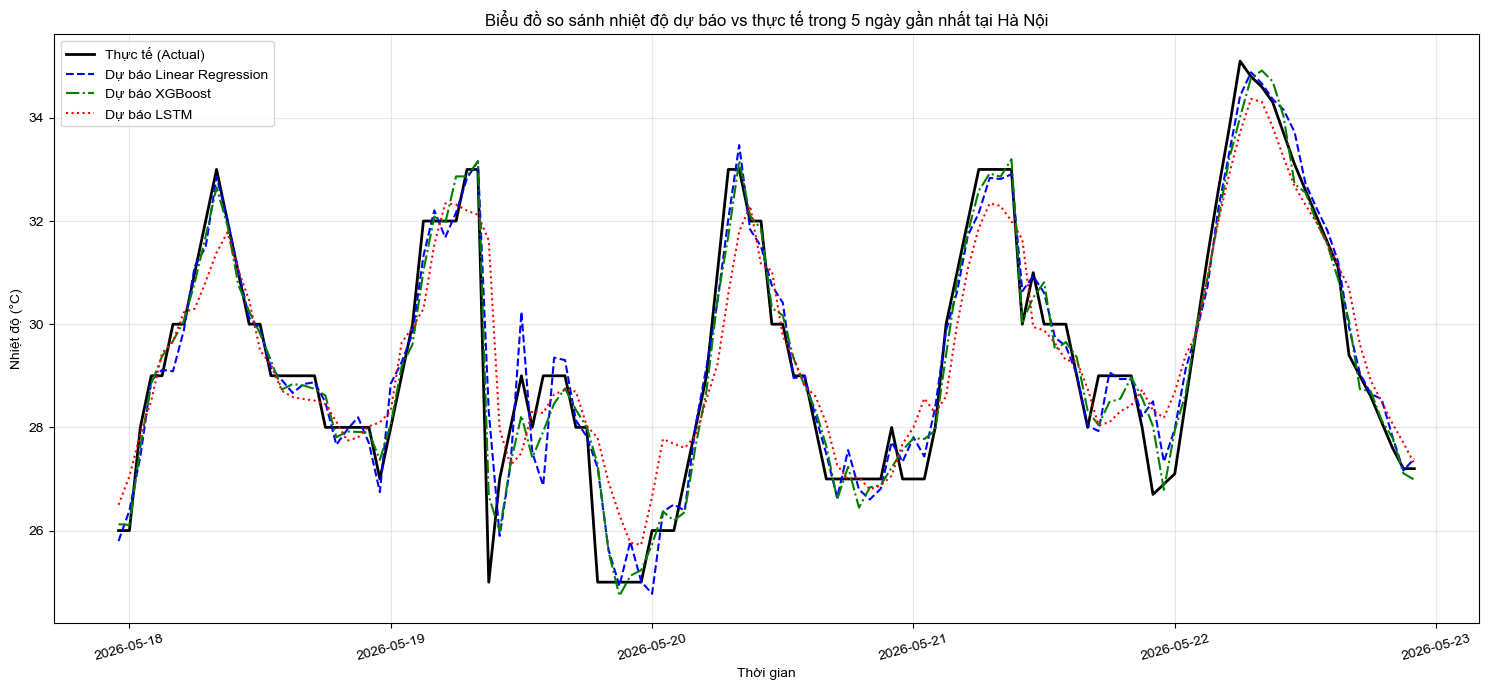

In [11]:
# 1. So sánh dạng bảng
df_so_sanh = pd.DataFrame({
    "Linear Regression": ket_qua_lr,
    "XGBoost Regressor": ket_qua_xgb,
    "LSTM Deep Learning": ket_qua_lstm
}).T

print("=== BẢNG SO SÁNH SAI SỐ CÁC MÔ HÌNH ===")
print(df_so_sanh)

# 2. Trực quan hóa dự báo 120 giờ cuối cùng trên tập Test cho thành phố Hà Nội
# Để vẽ biểu đồ, ta lấy phần đuôi dữ liệu tập Test của Hà Nội
df_test_hanoi = df_test[df_test['city'] == 'Ha Noi'].sort_values('time').tail(120)
thoi_gian_ve = df_test_hanoi['time'].values
nhiet_do_thuc_te = df_test_hanoi['temp'].values

# Lấy dự báo tương ứng bằng cách ánh xạ theo chỉ mục (index) của Pandas
df_test_lr_pred = pd.Series(y_pred_lr, index=df_test.index)
df_test_xgb_pred = pd.Series(y_pred_xgb, index=df_test.index)

lr_hanoi_pred = df_test_lr_pred.reindex(df_test_hanoi.index).values
xgb_hanoi_pred = df_test_xgb_pred.reindex(df_test_hanoi.index).values

# Dựng lại chỉ mục LSTM
def lay_chi_muc_lstm(df_data, seq_len=24):
    cac_chi_muc = []
    for ten_thanh_pho, nhom in df_data.groupby('city'):
        nhom_sorted = nhom.sort_values('time')
        cac_chi_muc.extend(nhom_sorted.index[seq_len:])
    return cac_chi_muc

chi_muc_lstm_test = lay_chi_muc_lstm(df_test, seq_len=24)
df_test_lstm_pred = pd.Series(y_pred_lstm, index=chi_muc_lstm_test)
lstm_hanoi_pred = df_test_lstm_pred.reindex(df_test_hanoi.index).values

# Vẽ biểu đồ so sánh đường nhiệt độ
plt.figure(figsize=(15, 7))
plt.plot(thoi_gian_ve, nhiet_do_thuc_te, label='Thực tế (Actual)', color='black', linewidth=2, linestyle='-')
plt.plot(thoi_gian_ve, lr_hanoi_pred, label='Dự báo Linear Regression', color='blue', linewidth=1.5, linestyle='--')
plt.plot(thoi_gian_ve, xgb_hanoi_pred, label='Dự báo XGBoost', color='green', linewidth=1.5, linestyle='-.')
plt.plot(thoi_gian_ve, lstm_hanoi_pred, label='Dự báo LSTM', color='red', linewidth=1.5, linestyle=':')

plt.title('Biểu đồ so sánh nhiệt độ dự báo vs thực tế trong 5 ngày gần nhất tại Hà Nội')
plt.xlabel('Thời gian')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('/Users/quangnguyentamhuu/.gemini/antigravity/brain/48b106db-d749-4764-9d18-6830a5dcc3bc/temp_prediction_comparison.png', dpi=150)
plt.show()


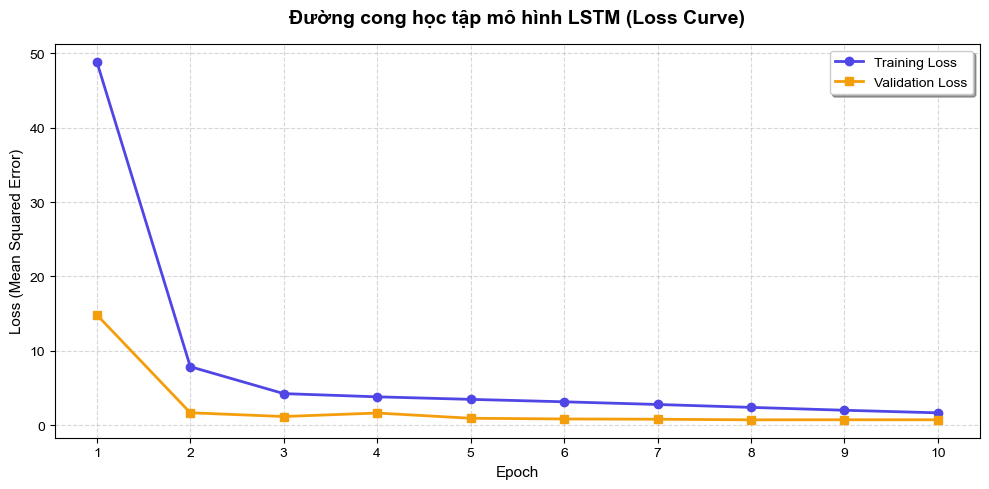

In [12]:
# Vẽ đường cong học tập (Learning Curve) của LSTM và lưu biểu đồ
if 'lich_su' in locals() and hasattr(lich_su, 'history'):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 11), lich_su.history['loss'], label='Training Loss', color='#4f46e5', marker='o', linewidth=2)
    plt.plot(range(1, 11), lich_su.history['val_loss'], label='Validation Loss', color='#f59e0b', marker='s', linewidth=2)
    plt.title('Đường cong học tập mô hình LSTM (Loss Curve)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('Loss (Mean Squared Error)', fontsize=11)
    plt.xticks(range(1, 11))
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('/Users/quangnguyentamhuu/.gemini/antigravity/brain/48b106db-d749-4764-9d18-6830a5dcc3bc/lstm_loss_curve.png', dpi=150)
    plt.show()
else:
    print('Không tìm thấy dữ liệu lịch sử huấn luyện LSTM.')


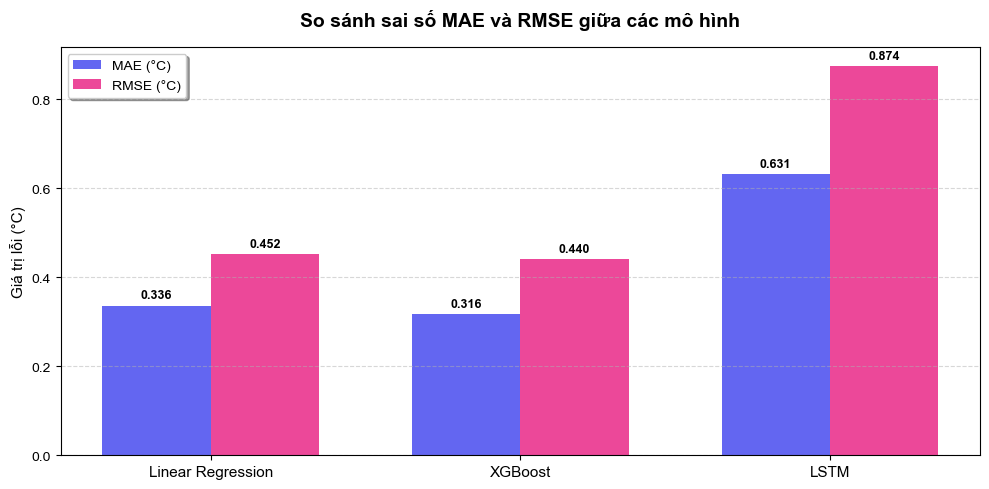

In [13]:
# Vẽ biểu đồ so sánh MAE và RMSE giữa các mô hình và lưu biểu đồ
models = ['Linear Regression', 'XGBoost', 'LSTM']
mae_vals = [ket_qua_lr['MAE'], ket_qua_xgb['MAE'], ket_qua_lstm['MAE']]
rmse_vals = [ket_qua_lr['RMSE'], ket_qua_xgb['RMSE'], ket_qua_lstm['RMSE']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, mae_vals, width, label='MAE (°C)', color='#6366f1')
rects2 = ax.bar(x + width/2, rmse_vals, width, label='RMSE (°C)', color='#ec4899')

ax.set_ylabel('Giá trị lỗi (°C)', fontsize=11)
ax.set_title('So sánh sai số MAE và RMSE giữa các mô hình', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(frameon=True, shadow=True)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.savefig('/Users/quangnguyentamhuu/.gemini/antigravity/brain/48b106db-d749-4764-9d18-6830a5dcc3bc/model_comparison_metrics.png', dpi=150)
plt.show()
